In [1]:
# 1. 기본 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# 2. 데이터 로딩
df = pd.read_csv('../data/Reviews.csv')
df.head(3), df.shape


(   Id   ProductId          UserId                      ProfileName  \
 0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
 1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
 2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
 
    HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
 0                     1                       1      5  1303862400   
 1                     0                       0      1  1346976000   
 2                     1                       1      4  1219017600   
 
                  Summary                                               Text  
 0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
 1      Not as Advertised  Product arrived labeled as Jumbo Salted Peanut...  
 2  "Delight" says it all  This is a confection that has been around a fe...  ,
 (568454, 10))

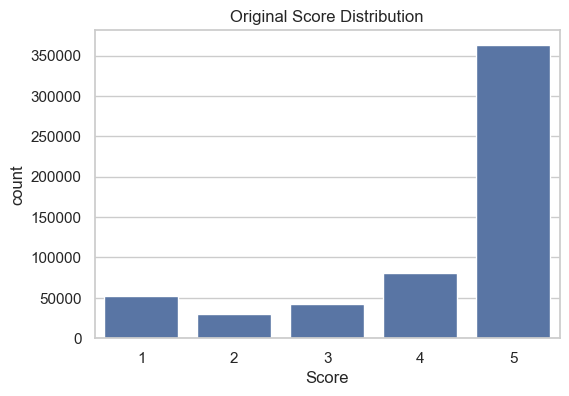

In [3]:
## 1. 데이터셋 개요
##- 총 리뷰 개수: `df.shape[0]`
##- 주요 컬럼: `Id`, `ProductId`, `UserId`, `ProfileName`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, `Score`, `Time`, `Summary`, `Text`

# 3. Score 분포 확인
plt.figure(figsize=(6,4))
sns.countplot(x='Score', data=df)
plt.title('Original Score Distribution')
plt.show()


In [4]:
# 4. 이진 감성 이진화 (1~2 negative, 4~5 positive, 3은 제거)
df = df[df['Score'] != 3].copy()
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)
print('Binary distribution:\n', df['Sentiment'].value_counts())


Binary distribution:
 Sentiment
1    443777
0     82037
Name: count, dtype: int64


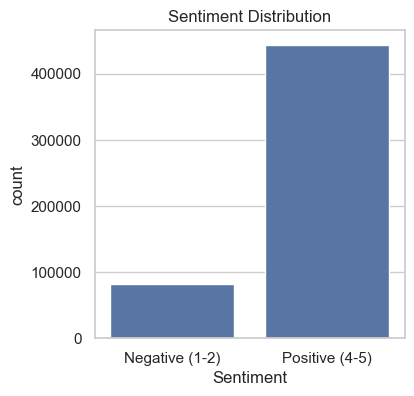

In [5]:
# 5. 감성 분포 시각화
plt.figure(figsize=(4,4))
sns.countplot(x='Sentiment', data=df)
plt.xticks([0,1], ['Negative (1-2)', 'Positive (4-5)'])
plt.title('Sentiment Distribution')
plt.show()


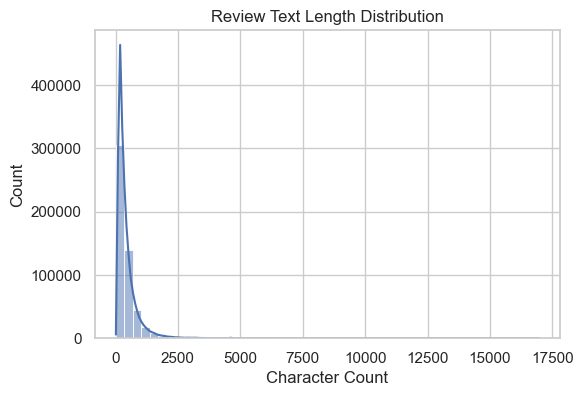

Text length: min=12, max=16952, mean=429.4, median=296.0


In [6]:
# 6. 리뷰 텍스트 길이 분석
df['text_len'] = df['Text'].str.len()
plt.figure(figsize=(6,4))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title('Review Text Length Distribution')
plt.xlabel('Character Count')
plt.show()
print('Text length: min=%d, max=%d, mean=%.1f, median=%.1f' %
      (df['text_len'].min(), df['text_len'].max(),
       df['text_len'].mean(), df['text_len'].median()))


In [7]:
# 7. 샘플 리뷰 예시 출력 (긍정/부정 각각 3개씩)
for label, label_name in [(0, 'Negative'), (1, 'Positive')]:
    print(f'\n--- {label_name} Examples ---')
    for text in df[df['Sentiment']==label]['Text'].sample(3, random_state=42).values:
        print('- ', text[:200].replace('\n',' ') + '...')



--- Negative Examples ---
-  I have an absolute passion for deep, dark hot chocolate. I want chocolate which tastes like *chocolate*, rich and flavorful, with a hint of a bite. You can savor chocolate like that.<br />What I have ...
-  This drink is so "super energy" it's almost frightening.  Several members of my family tasted it and the consensus was that it might, indeed, give you a boost but the taste...some even compared it to ...
-  I'm sticking with what used to be carnation, now nestles malt. this stuff tastes like powdered milk with a hint of soy....

--- Positive Examples ---
-  I have started every morning for the last 7 months with a cup of Ganocafe Classic coffee. In my opinion it must be providing some benefits, I haven't had even one cold or any flu in that time. At age ...
-  Thank goodness this pasta makes life for a gluten-free lifestyle so much more enjoyable.  It cooks with enough firm texture, unlike other gluten-free items that become too soggy or a mush.  The pa

In [8]:
# 마지막에 추가
df.to_csv('../data/preprocessed.csv', index=False)
